# Part 5: Customer Lifetime Value Analysis and Future Spending Prediction

## 1. Business Problem Understanding
The ongoing business challenge is to increase revenue organically by focusing on existing customers rather than relying on expensive new customer acquisition.

**Customer Lifetime Value (CLV/LTV)** represents the total revenue a business can expect from a single customer throughout their relationship. Increasing LTV is crucial because retaining existing customers is usually much cheaper and more profitable than acquiring new ones. Future spending prediction allows the business to segment users and target those who have high potential or identify those at risk of churning.

## 2. Data Understanding
Let's load our given dataset and inspect its structure.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans

# Load data
df = pd.read_csv('part_5_customer_ltv_prediction.csv')
display(df.head())
display(df.info())

,CustomerID,Age,AnnualIncome,WebsiteVisits,AppSessions,PreviousOrders,AverageOrderValue,DaysSinceLastPurchase,ReturnRate,CancellationRate,LoyaltyTier,DiscountUsedLastCampaign,Year1Spending,FutureSpending
0,LTV00001,33,64196.02,145,61,19,1403.79,242,0.136,0.028,Gold,No,25356.80,12438.46
1,LTV00002,46,69889.53,153,111,2,988.47,223,0.126,0.067,Silver,Yes,2768.68,5860.22
2,LTV00003,20,83269.51,175,112,34,2386.24,101,0.026,0.087,Silver,No,80895.63,39203.34
3,LTV00004,44,79914.63,22,80,0,1121.87,98,0.037,0.004,Gold,Yes,874.95,3157.73
4,LTV00005,26,84091.39,24,166,12,1942.48,256,0.052,0.004,Gold,No,22962.40,11423.53


<class 'pandas.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                1400 non-null   str    
 1   Age                       1400 non-null   int64  
 2   AnnualIncome              1391 non-null   float64
 3   WebsiteVisits             1400 non-null   int64  
 4   AppSessions               1400 non-null   int64  
 5   PreviousOrders            1400 non-null   int64  
 6   AverageOrderValue         1390 non-null   float64
 7   DaysSinceLastPurchase     1400 non-null   int64  
 8   ReturnRate                1400 non-null   float64
 9   CancellationRate          1400 non-null   float64
 10  LoyaltyTier               1400 non-null   str    
 11  DiscountUsedLastCampaign  1400 non-null   str    
 12  Year1Spending             1400 non-null   float64
 13  FutureSpending            1400 non-null   float64
dtypes: float64(6), int6

None

## 3. Data Cleaning and Feature Engineering
We will handle any missing or duplicate data, and create features such as target engagement score and spending volumes.

In [2]:
# Handle missing values and duplicates
df = df.dropna()
df = df.drop_duplicates()

# Feature Engineering
# 1. Total Engagement 
df['TotalEngagement'] = df['WebsiteVisits'] + df['AppSessions']

# 2. Estimated Total Previous Spending
df['TotalPreviousSpending'] = df['PreviousOrders'] * df['AverageOrderValue']

print(f"Data size after cleaning: {df.shape}")
df[['TotalEngagement', 'TotalPreviousSpending']].head()

Data size after cleaning: (1382, 16)


,TotalEngagement,TotalPreviousSpending
0,206,26672.01
1,264,1976.94
2,287,81132.16
3,102,0.00
4,190,23309.76


## 4. Exploratory Data Analysis (EDA)
Visualizing the relationships between customer behaviors and our target variable, `FutureSpending`.

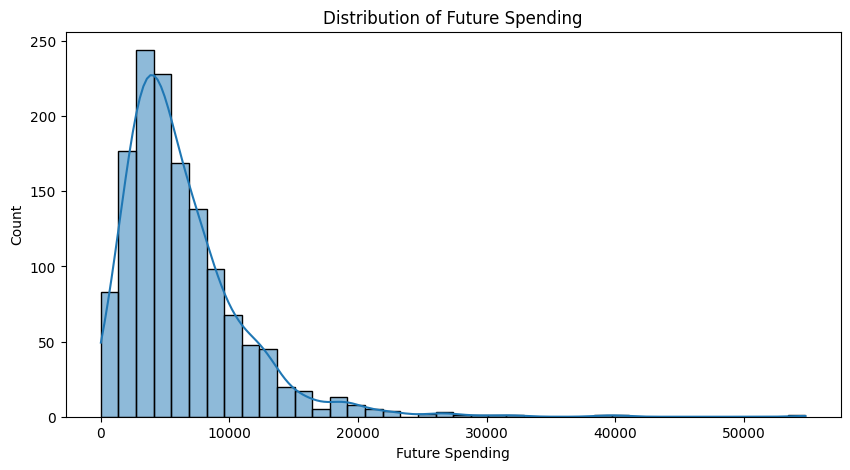

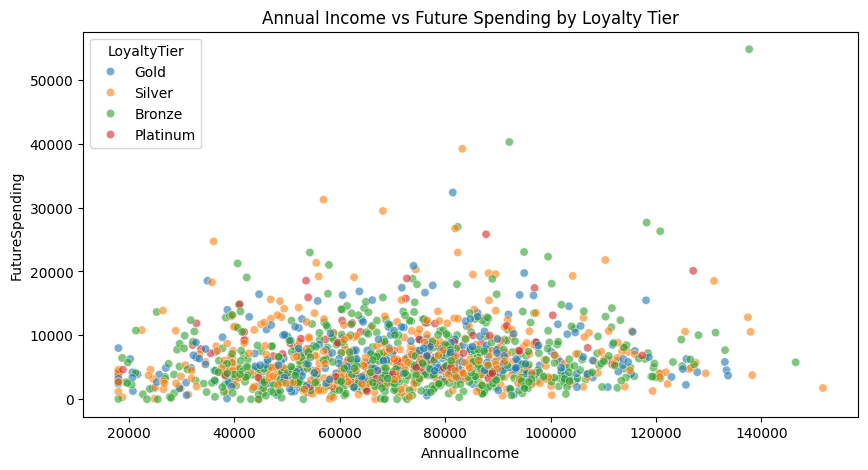

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['FutureSpending'], bins=40, kde=True)
plt.title('Distribution of Future Spending')
plt.xlabel('Future Spending')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x='AnnualIncome', y='FutureSpending', hue='LoyaltyTier', data=df, alpha=0.6)
plt.title('Annual Income vs Future Spending by Loyalty Tier')
plt.show()

## 5. Customer Segmentation
We can segment customers using business logic categorizations based on `FutureSpending` predictions and behavior.

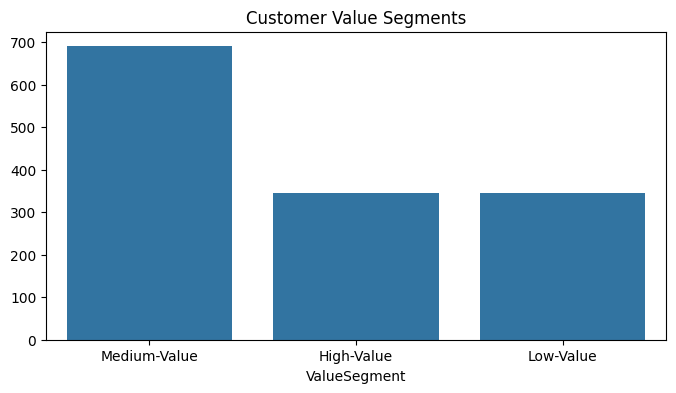

In [4]:
def assign_segment(row):
    if row['FutureSpending'] > df['FutureSpending'].quantile(0.75):
        return 'High-Value'
    elif row['FutureSpending'] > df['FutureSpending'].quantile(0.25):
        return 'Medium-Value'
    else:
        return 'Low-Value'
        
df['ValueSegment'] = df.apply(assign_segment, axis=1)

segment_counts = df['ValueSegment'].value_counts()
plt.figure(figsize=(8,4))
sns.barplot(x=segment_counts.index, y=segment_counts.values)
plt.title('Customer Value Segments')
plt.show()

## 6. Future Spending Prediction
We treat this as a regression problem. We build a Random Forest Regressor to predict `FutureSpending`.

In [5]:
target = 'FutureSpending'
features = [c for c in df.columns if c not in [target, 'CustomerID', 'ValueSegment']]

X = df[features]
y = df[target]

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Summary:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

C:\Users\shiva\AppData\Local\Temp\ipykernel_10732\608844307.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


Model Evaluation Summary:
MAE: 1136.26
MSE: 2012615.25
RMSE: 1418.67
R² Score: 0.9045


## 7. Business Recommendations

1. **Premium Offers**: Target 'High-Value' customers for VIP access and premium items since their purchasing behavior indicates a strong willingness to spend.
2. **Discount Interventions**: Use targeted discounts effectively on 'Medium-Value' customers who exhibit high `TotalEngagement` but average `TotalPreviousSpending`. These customers have intent, but may need incentives.
3. **Re-Engagement**: Customers with high `DaysSinceLastPurchase` and a previously high `AverageOrderValue` should receive immediate re-engagement campaigns.
4. **Avoid Expensive Offers**: Customers categorized as 'Low-Value' with high `CancellationRate` should be excluded from high-cost retention campaigns to maximize ROI.